# 📊 Diagnostic Evaluation Suite (Local & Kaggle Native)

Chào mừng bạn đến với Notebook đánh giá chuyên sâu cho hệ thống **Mamba Anomaly Detection Pipeline**.

Notebook này được thiết kế dựa trên logic cốt lõi của **`src/training/eval.py`** kết hợp với cách tải dữ liệu, tự động điều chỉnh tham số (auto-scaling) và hiển thị kết quả trực quan từ notebook huấn luyện.

### 🌟 Các Tính Năng Vượt Trội:
1. **Tự động cấu hình môi trường**: Tự động phát hiện nếu đang chạy trên **Kaggle** để cấu hình `sys.path` và các thư mục chứa dữ liệu đầu vào `/kaggle/input/datasets/sunbv21/dataset-bearings/`.
2. **Đánh giá đa mô hình (Multi-Model Evaluation)**: Hỗ trợ 6 mô hình cốt lõi: `LSTM`, `PatchLSTM`, `ModernTCN`, `PatchTST`, `Mamba-Hybrid`, và `MambaTS-Official`.
3. **Chống rò rỉ dữ liệu (Leakage-Free Calibration)**: Tính toán ngưỡng phát hiện bất thường (POT, Robust, 3-Sigma, GMM, Percentile, Optimal) hoàn toàn trên tập dữ liệu lành mạnh (`bearing_labels == 0`) trong khoảng `skip_ratio` đến `train_ratio`.
4. **Trực quan hóa Cao cấp**: So sánh hiệu năng qua sơ đồ 2x2 và vẽ luồng điểm bất thường (Anomaly Score Flow) cùng các ngưỡng động theo thời gian cho từng vòng bi.

---


In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 36.5 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


In [2]:
import os
import sys

# 1. Phát hiện môi trường Kaggle
is_kaggle = os.path.exists('/kaggle')
print(f'Is running on Kaggle: {is_kaggle}')

if is_kaggle:
    # Thêm code nguồn từ Kaggle input vào sys.path
    kaggle_source_root = '/kaggle/input/datasets/sunbv21/mamba-sft-source'
    if kaggle_source_root not in sys.path:
        sys.path.append(kaggle_source_root)
    project_root = kaggle_source_root
    
    # Cấu hình đường dẫn dữ liệu trên Kaggle
    train_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B02", 
                  "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
    test_dirs = ["/kaggle/input/datasets/sunbv21/dataset-bearings/B01",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B03",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B04",
                 "/kaggle/input/datasets/sunbv21/dataset-bearings/B05"]
    
    # Thư mục chứa checkpoints .pth
    models_dir = "/kaggle/working/results/models"
    pretrained_models_dir = "/kaggle/input/datasets/sunbv21/models-pth"
    print(f'-> [Kaggle] project_root: {project_root}')
    print(f'-> [Kaggle] models_dir: {models_dir}')
else:
    # Cấu hình cục bộ
    project_root = os.path.abspath("../")
    if project_root not in sys.path:
        sys.path.append(project_root)
        
    train_dirs = ["data/processed/B02", "data/processed/B05"]
    test_dirs = ["data/processed/B01", "data/processed/B03", "data/processed/B04", "data/processed/B05"]
    models_dir = os.path.join(project_root, "results/models")
    print(f'-> [Local] project_root: {project_root}')
    print(f'-> [Local] models_dir: {models_dir}')


Is running on Kaggle: True
-> [Kaggle] project_root: /kaggle/input/datasets/sunbv21/mamba-sft-source
-> [Kaggle] models_dir: /kaggle/input/datasets/sunbv21/models-pth


In [3]:
import time
import yaml
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc as auc_score_func

from src.data import MultiBearingDataset
from src.models.mamba import HybridMambaCNN, MambaTSOfficial, MambaTSConfig
from src.models.baselines.lstm import LSTMForecaster
from src.models.baselines.modern_tcn import ModernTCNForecaster
from src.models.baselines.patch_models import PatchTST
from src.models.baselines.patch_models import PatchLSTM
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import (
    calculate_threshold_3sigma, calculate_threshold_robust, 
    calculate_threshold_percentile, calculate_threshold_gmm, 
    find_best_threshold, calculate_metrics, calculate_threshold_pot
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


In [4]:
config_path = os.path.join(project_root, 'configs/nano.yaml')
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("--- Cấu hình Config ---")
print(yaml.dump(config, default_flow_style=False))


--- Cấu hình Config ---
data:
  highpass_freq: 2000
  horizon: 1024
  label_strategy: rms
  lookback: 4096
  processed_dir: data/processed/B04
  raw_dir: data/raw/B04
  sampling_rate: 128000
  skip_ratio: 0.05
  test_datasets:
  - data/processed/B02
  - data/processed/B03
  - data/processed/B04
  - data/processed/B05
  train_datasets:
  - data/processed/B02
  - data/processed/B05
  train_ratio: 0.4
  window_stride: 1024
logging:
  project_name: Hybrid_Mamba_CNN_Nano
  use_wandb: false
model:
  auto_scale_baselines: true
  bidirectional: false
  cnn_out_channels: 64
  decomp_kernel: 25
  mamba_d_conv: 3
  mamba_d_model: 64
  mamba_d_state: 16
  mamba_expand: 3
  mamba_n_layer: 4
  patch_size: 64
  patch_stride: 32
  trend_downsample: 64
training:
  batch_size: 128
  device: cuda
  epochs: 10
  learning_rate: 5e-4



In [5]:
# 3. Tải dữ liệu bằng MultiBearingDataset
window_stride = config['data'].get('window_stride', 2048)
lookback = config['data'].get('lookback', 16384)
horizon = config['data'].get('horizon', 1024)
sampling_rate = config['data'].get('sampling_rate', 128000)
highpass_freq = config['data'].get('highpass_freq', 2000)
train_ratio = config['data'].get('train_ratio', 0.5)
skip_ratio = config['data'].get('skip_ratio', 0.1)
label_strategy = config['data'].get('label_strategy', 'rms')
batch_size = 32

print('Loading train datasets...')
train_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='train',
    file_sample_ratio=1, train_ratio=train_ratio, skip_ratio=skip_ratio, 
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)
oc_stats = train_dataset.oc_stats

print('Loading val datasets...')
val_dataset = MultiBearingDataset(
    train_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='val',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio, 
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)

print('Loading testing datasets...')
test_dataset = MultiBearingDataset(
    test_dirs, lookback=lookback, horizon=horizon, stride=window_stride, split='test',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=train_ratio, skip_ratio=skip_ratio, 
    normalize=False, highpass_freq=highpass_freq, sampling_rate=sampling_rate, label_strategy=label_strategy
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('\n--- Dữ liệu tải thành công ---')
print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')


Loading training datasets for Dynamic Statistics baseline...
Loading testing datasets...

--- Dữ liệu tải thành công ---
Test dataset samples: 524692


In [6]:
# 5. Định nghĩa Hàm Đánh giá evaluate_model (Per-Bearing & Leakage-Free) với Đo lường Độ trễ Chi tiết
def evaluate_model(name, model, test_loader, config, device):
    model.to(device)
    model.eval()

    print(f"\n>>> ĐANG ĐÁNH GIÁ MÔ HÌNH: {name}")
    
    macro_metrics = {
        t_name: {"F1": [], "FAR": [], "AUC": [], "AUPRC": []} 
        for t_name in ["3-Sigma", "Robust", "Percentile", "POT", "Self-Learn", "Optimal"]
    }
    
    macro_forecasting = {
        "MAE": [], "MSE": [], "RMSE": [], "MAPE": []
    }
    
    # Khởi tạo các danh sách đo độ trễ
    transfer_latencies = []
    inf_latencies = []
    scoring_latencies = []
    decision_latencies = []
    total_eval_latencies = []
    
    calib_times = {
        "3-Sigma": [],
        "Robust": [],
        "Percentile": [],
        "POT": [],
        "Self-Learn": [],
        "Optimal": []
    }
    
    skip_ratio = config['data'].get('skip_ratio', 0.1)
    train_ratio = config['data'].get('train_ratio', 0.5)

    test_datasets = test_loader.dataset.datasets if hasattr(test_loader.dataset, 'datasets') else [test_loader.dataset]
    last_bearing_data = {}

    for test_idx, ds in enumerate(test_datasets):
        bearing_name = os.path.basename(ds.data_dir) if hasattr(ds, 'data_dir') else f"Dataset_{test_idx}"
        loader = DataLoader(ds, batch_size=config['training'].get('batch_size', 128), shuffle=False)
        
        bearing_scores = []
        bearing_labels = []
        bearing_mae_list = []
        bearing_mse_list = []
        bearing_mape_list = []
        
        with torch.no_grad():
            for batch in tqdm(loader, desc=f"Inference {bearing_name}", leave=False):
                # 1. Đo lường thời gian truyền dữ liệu (CPU -> GPU)
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t0 = time.time()
                
                x = batch[0].to(device)
                y = batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                oc = batch[4].to(device) if len(batch) > 4 else None
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t1 = time.time()
                
                # 2. Đo lường thời gian Model Inference (Forward Pass)
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    elif oc is not None and isinstance(model, MambaTSOfficial):
                        y_pred = model(x, oc)
                    else:
                        y_pred = model(x)
                        
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t2 = time.time()
                
                # 3. Đo lường thời gian Tính điểm bất thường (Anomaly Scoring)
                scores = calculate_anomaly_score(y, y_pred, metric='mse', normalized=False)
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t3 = time.time()
                
                # 4. Đo lường thời gian Ra quyết định (Threshold Decision)
                # Giả lập phép so sánh ngưỡng thời gian thực
                dummy_threshold = 0.5
                is_anomaly = scores > dummy_threshold
                
                if device.type == 'cuda':
                    torch.cuda.synchronize()
                t4 = time.time()
                
                bearing_scores.extend(scores.tolist())
                if len(batch) > 3:
                    bearing_labels.extend(batch[3].cpu().numpy().tolist())
                else:
                    bearing_labels.extend([0] * x.size(0))

                # Tính toán tốc độ / độ trễ trên mỗi sample (ms/sample)
                n_samples = x.size(0)
                transfer_ms = (t1 - t0) * 1000 / n_samples
                inf_ms = (t2 - t1) * 1000 / n_samples
                score_ms = (t3 - t2) * 1000 / n_samples
                decision_ms = (t4 - t3) * 1000 / n_samples
                total_ms = (t4 - t0) * 1000 / n_samples
                
                transfer_latencies.append(transfer_ms)
                inf_latencies.append(inf_ms)
                scoring_latencies.append(score_ms)
                decision_latencies.append(decision_ms)
                total_eval_latencies.append(total_ms)

                y_cpu = y.detach().cpu().numpy()
                y_pred_cpu = y_pred.detach().cpu().numpy()
                
                batch_mae = np.mean(np.abs(y_cpu - y_pred_cpu))
                batch_mse = np.mean((y_cpu - y_pred_cpu) ** 2)
                epsilon = 1e-5
                batch_mape = np.mean(np.abs(y_cpu - y_pred_cpu) / (np.abs(y_cpu) + epsilon)) * 100
                
                bearing_mae_list.append(batch_mae)
                bearing_mse_list.append(batch_mse)
                bearing_mape_list.append(batch_mape)

        bearing_scores = np.array(bearing_scores)
        bearing_labels = np.array(bearing_labels, dtype=int)
        
        n_fault = int(bearing_labels.sum())
        n_total = len(bearing_labels)

        bearing_mae = np.mean(bearing_mae_list)
        bearing_mse = np.mean(bearing_mse_list)
        bearing_rmse = np.sqrt(bearing_mse)
        bearing_mape = np.mean(bearing_mape_list)
        
        macro_forecasting["MAE"].append(bearing_mae)
        macro_forecasting["MSE"].append(bearing_mse)
        macro_forecasting["RMSE"].append(bearing_rmse)
        macro_forecasting["MAPE"].append(bearing_mape)
        
        # Tính LOCAL THRESHOLD đảm bảo leakage-free
        skip_end = int(n_total * skip_ratio)
        train_end = int(n_total * (skip_ratio + train_ratio))
        
        normal_indices = np.where(bearing_labels == 0)[0]
        if len(normal_indices) > 0:
            train_end = min(train_end, normal_indices[-1] + 1)
            
        if train_end > skip_end:
            healthy_subset = bearing_scores[skip_end:train_end]
            healthy_labels = bearing_labels[skip_end:train_end]
            healthy_scores = healthy_subset[healthy_labels == 0]
            if len(healthy_scores) == 0:
                healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
        else:
            healthy_scores = bearing_scores[:max(1, int(n_total * 0.1))]
            
        # Đo lường thời gian hiệu chuẩn từng thuật toán ngưỡng
        t_cal = time.time()
        local_th_3s  = calculate_threshold_3sigma(healthy_scores)
        calib_times["3-Sigma"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_rb  = calculate_threshold_robust(healthy_scores)
        calib_times["Robust"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_pc  = calculate_threshold_percentile(healthy_scores, q=99.7)
        calib_times["Percentile"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_pot = calculate_threshold_pot(healthy_scores, q=1e-3)
        calib_times["POT"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_gmm = calculate_threshold_gmm(bearing_scores)
        calib_times["Self-Learn"].append((time.time() - t_cal) * 1000)
        
        t_cal = time.time()
        local_th_opt, _ = find_best_threshold(bearing_scores, bearing_labels)
        calib_times["Optimal"].append((time.time() - t_cal) * 1000)

        if len(np.unique(bearing_labels)) > 1:
            precision_path, recall_path, _ = precision_recall_curve(bearing_labels, bearing_scores)
            bearing_auprc = auc_score_func(recall_path, precision_path)
        else:
            bearing_auprc = 0.0

        thresholds = [
            ("3-Sigma", local_th_3s), ("Robust", local_th_rb), ("Percentile", local_th_pc),
            ("POT", local_th_pot), ("Self-Learn", local_th_gmm), ("Optimal", local_th_opt)
        ]
        
        for t_name, t_val in thresholds:
            m = calculate_metrics(bearing_scores, bearing_labels, t_val)
            macro_metrics[t_name]["F1"].append(m.get('F1', 0))
            macro_metrics[t_name]["FAR"].append(m.get('FAR', 0))
            macro_metrics[t_name]["AUC"].append(m.get('AUC', 0))
            macro_metrics[t_name]["AUPRC"].append(bearing_auprc)
            
        # Lưu trữ dữ liệu của vòng bi cuối cùng để trực quan hóa ở Cell 9
        last_bearing_data = {
            'bearing_name': bearing_name,
            'scores': bearing_scores,
            'labels': bearing_labels,
            'th_3sigma': local_th_3s,
            'th_robust': local_th_rb,
            'th_pot': local_th_pot
        }

    # Tính toán trung bình các chỉ số thời gian
    avg_transfer_lat = float(np.mean(transfer_latencies))
    avg_inf_lat = float(np.mean(inf_latencies))
    avg_scoring_lat = float(np.mean(scoring_latencies))
    avg_decision_lat = float(np.mean(decision_latencies))
    avg_total_eval_lat = float(np.mean(total_eval_latencies))
    
    avg_calib_times = {k: float(np.mean(v)) for k, v in calib_times.items()}
    
    avg_mae = np.mean(macro_forecasting["MAE"])
    avg_mse = np.mean(macro_forecasting["MSE"])
    avg_rmse = np.mean(macro_forecasting["RMSE"])
    avg_mape = np.mean(macro_forecasting["MAPE"])

    print(f"\n============================================================")
    print(f">>> MACRO-AVERAGE PERFORMANCE ({len(test_datasets)} Bearings)")
    print(f"   [Forecasting Metrics] > MAE: {avg_mae:.6f} | MSE: {avg_mse:.6f} | RMSE: {avg_rmse:.6f} | MAPE: {avg_mape:.4f}%")
    print(f"------------------------------------------------------------")
    print(f"   [Real-time Evaluation Latency Breakdown (per sample)]:")
    print(f"     * Data Transfer (CPU->GPU): {avg_transfer_lat:.4f} ms")
    print(f"     * Model Inference (Forward): {avg_inf_lat:.4f} ms")
    print(f"     * Anomaly Scoring:           {avg_scoring_lat:.4f} ms")
    print(f"     * Decision (Threshold Cmp):  {avg_decision_lat:.4f} ms")
    print(f"     * TOTAL REAL LATENCY:        {avg_total_eval_lat:.4f} ms/sample")
    print(f"------------------------------------------------------------")
    print(f"   [Threshold Calibration Overhead (per bearing)]:")
    for k, v in avg_calib_times.items():
        print(f"     * {k:<12}: {v:.4f} ms")
    print(f"============================================================")

    results = {
        'name': name,
        'f1_3s': float(np.mean(macro_metrics["3-Sigma"]["F1"])),
        'f1_rb': float(np.mean(macro_metrics["Robust"]["F1"])),
        'f1_pot': float(np.mean(macro_metrics["POT"]["F1"])),
        'auc': float(np.mean(macro_metrics["POT"]["AUC"])),
        'far_pot': float(np.mean(macro_metrics["POT"]["FAR"])),
        'auprc': float(np.mean(macro_metrics["POT"]["AUPRC"])),
        'latency': float(avg_total_eval_lat),
        'mae': float(avg_mae),
        'mse': float(avg_mse),
        'rmse': float(avg_rmse),
        'mape': float(avg_mape),
        'last_bearing': last_bearing_data,
        'latency_breakdown': {
            'data_transfer': avg_transfer_lat,
            'inference': avg_inf_lat,
            'scoring': avg_scoring_lat,
            'decision': avg_decision_lat,
            'total': avg_total_eval_lat
        },
        'calib_latencies': avg_calib_times
    }
    
    print(f"Đã hoàn thành đánh giá: {name} | F1 (POT) = {results['f1_pot']:.4f} | MSE = {results['mse']:.6f}")
    return results


## 3.5. Định nghĩa Early Stopping
Lớp hỗ trợ dừng sớm khi tổn thất (loss) trên tập Validation không giảm sau một số epoch liên tiếp.

In [ ]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


## 3.6. Định nghĩa Hàm Huấn luyện Mô hình
Hàm huấn luyện các mô hình baselines và Mamba với Huber Loss và cơ chế dừng sớm (Early Stopping) trên tập Validation.

In [ ]:
def train_one_model_in_notebook(name, model, train_loader, val_loader, config, device, config_name='nano', save_dir=None):
    if save_dir is None:
        save_dir = globals().get('models_dir', 'results/models')
    os.makedirs(save_dir, exist_ok=True)
    
    print(f'\n>>> Huấn luyện {name} (Cấu hình: {config_name})...')
    model.to(device)
    
    lr = float(config['training'].get('learning_rate', 5e-4))
    epochs = int(config['training'].get('epochs', 10))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr * 1e-2)
    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
    
    model_slug = name.lower().replace('-', '_')
    best_model_path = os.path.join(save_dir, f'{model_slug}_{config_name}_best.pth')
    early_stopping = EarlyStopping(patience=3, verbose=True, path=best_model_path)
    
    losses = []
    start_train = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f'{name} - Epoch {epoch}/{epochs}')
        for batch in pbar:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                if stats is not None and isinstance(model, HybridMambaCNN):
                    y_pred = model(x, stats)
                else:
                    y_pred = model(x)
                loss = criterion(y_pred, y)
            
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
            
        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch}/{epochs}] - Train Loss: {avg_loss:.6f}')
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    if stats is not None and isinstance(model, HybridMambaCNN):
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(val_loader)
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch [{epoch}/{epochs}] - Val Loss: {avg_val_loss:.6f} | LR: {current_lr:.2e}')
        
        scheduler.step()
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print('Early stopping kích hoạt!')
            break
            
    train_duration = time.time() - start_train
    print(f'Huấn luyện tốn {train_duration:.2f} giây')
    
    # Tải lại trọng số tốt nhất
    print(f'Loading best model weights from {best_model_path}...')
    model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))
    
    # Giải phóng bộ nhớ
    optimizer.zero_grad(set_to_none=True)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    return {
        'name': name,
        'losses': losses,
        'train_duration': train_duration,
        'best_model_path': best_model_path
    }


In [ ]:
# 6. Khởi tạo Mô hình & Tải Trọng số Checkpoints (Dynamic & Auto-Scaled)
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def find_closest_lstm(target, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for h in range(8, 1024, 2):
        model = LSTMForecaster(input_dim=2, hidden_dim=h, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = h
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_patch_lstm(target, patch_size, stride, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = PatchLSTM(in_channels=2, patch_size=patch_size, stride=stride, d_model=d, num_layers=3, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_modern_tcn(target, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = ModernTCNForecaster(input_dim=2, d_model=d, num_layers=3, kernel_size=17, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params

def find_closest_patchtst(target, lookback, patch_size, stride, horizon):
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 4):
        nhead = 4 if d >= 4 else 1
        if d % 4 != 0:
            nhead = 2 if d % 2 == 0 else 1
        model = PatchTST(in_channels=2, lookback=lookback, patch_size=patch_size, stride=stride, d_model=d, nhead=nhead, num_layers=4, horizon=horizon)
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params


def find_closest_simple_mamba(target, lookback, patch_size, stride, horizon, mamba_n_layer=4, mamba_d_state=16, mamba_d_conv=4, mamba_expand=2, mamba_version=1):
    from src.models.mamba import SimpleMamba
    best_dim = 8
    best_params = 0
    min_diff = float('inf')
    for d in range(8, 1024, 2):
        model = SimpleMamba({
            'model': {
                'mamba_version': mamba_version,
                'mamba_d_model': d,
                'mamba_n_layer': mamba_n_layer,
                'mamba_d_state': mamba_d_state,
                'mamba_d_conv': mamba_d_conv,
                'mamba_expand': mamba_expand,
                'forecast_len': horizon,
                'patch_size': patch_size,
                'stride': stride,
                'in_channels': 2,
                'lookback': lookback,
            },
            'data': {'patch_size': patch_size, 'stride': stride, 'lookback': lookback}
        })
        p = count_parameters(model)
        diff = abs(p - target)
        if diff < min_diff:
            min_diff = diff
            best_dim = d
            best_params = p
        if p > target and diff > min_diff:
            break
    return best_dim, best_params


# Lấy các tham số cấu hình model từ config
patch_size = config.get('model', {}).get('patch_size', 64)
patch_stride = config.get('model', {}).get('patch_stride', 32)
trend_downsample = config.get('model', {}).get('trend_downsample', 1)

# 1. Khởi tạo Mamba1-Hybrid
mamba_model = HybridMambaCNN({
    'model': {
        'mamba_version': 1,
        'mamba_d_model': config.get('model', {}).get('mamba_d_model', 64),
        'mamba_n_layer': config.get('model', {}).get('mamba_n_layer', 4),
        'mamba_d_state': config.get('model', {}).get('mamba_d_state', 16),
        'mamba_d_conv': config.get('model', {}).get('mamba_d_conv', 4),
        'mamba_expand': config.get('model', {}).get('mamba_expand', 2),
        'forecast_len': horizon,
        'patch_size': patch_size,
        'stride': patch_stride,
        'trend_downsample': trend_downsample,
        'in_channels': 2, 'lookback': lookback,
        'decomp_kernel': config.get('model', {}).get('decomp_kernel', 25),
        'use_multiscale': False,
        'use_revin': False,
        'use_decomposition': True,
        'use_stats': True,
    },
    'data': {
        'patch_size': patch_size,
        'stride': patch_stride,
        'lookback': lookback
    }
})

mamba_params = count_parameters(mamba_model)
auto_scale = config.get('model', {}).get('auto_scale_baselines', False)

if auto_scale:
    print(f"\n[AUTO-SCALE] Tự động điều chỉnh baselines theo ngân sách tham số của Mamba (~{mamba_params:,} params)...")
    lstm_dim, lstm_p = find_closest_lstm(mamba_params, horizon)
    pl_dim, pl_p = find_closest_patch_lstm(mamba_params, patch_size, patch_stride, horizon)
    tcn_dim, tcn_p = find_closest_modern_tcn(mamba_params, horizon)
    pt_dim, pt_p = find_closest_patchtst(mamba_params, lookback, patch_size, patch_stride, horizon)
    
    print(f"  -> LSTM hidden_dim={lstm_dim} ({lstm_p:,} params)")
    print(f"  -> PatchLSTM d_model={pl_dim} ({pl_p:,} params)")
    print(f"  -> ModernTCN d_model={tcn_dim} ({tcn_p:,} params)")
    print(f"  -> PatchTST d_model={pt_dim} ({pt_p:,} params)")
    print(f"  -> Simple-Mamba d_model={sm_dim} ({sm_p:,} params)")
    
    lstm_forecaster = LSTMForecaster(input_dim=2, hidden_dim=lstm_dim, num_layers=3, horizon=horizon)
    patch_lstm = PatchLSTM(in_channels=2, patch_size=patch_size, stride=patch_stride, d_model=pl_dim, num_layers=3, horizon=horizon)
    modern_tcn = ModernTCNForecaster(input_dim=2, d_model=tcn_dim, num_layers=3, kernel_size=17, horizon=horizon)
    
    nhead = 4 if pt_dim >= 4 else 1
    if pt_dim % 4 != 0:
        nhead = 2 if pt_dim % 2 == 0 else 1
    patchtst = PatchTST(in_channels=2, lookback=lookback, patch_size=patch_size, stride=patch_stride, d_model=pt_dim, nhead=nhead, num_layers=4, horizon=horizon)
else:
    print("\n[AUTO-SCALE] Sử dụng tham số mặc định cho baselines...")
    lstm_forecaster = LSTMForecaster(input_dim=2, hidden_dim=122, num_layers=3, horizon=horizon)
    patch_lstm = PatchLSTM(in_channels=2, patch_size=64, stride=64, d_model=112, num_layers=3, horizon=horizon)
    modern_tcn = ModernTCNForecaster(input_dim=2, d_model=144, num_layers=3, kernel_size=17, horizon=horizon)
    patchtst = PatchTST(in_channels=2, lookback=lookback, d_model=28, nhead=4, num_layers=4, horizon=horizon)
    simple_mamba = SimpleMamba({
        'model': {
            'mamba_version': config.get('model', {}).get('mamba_version', 1),
            'mamba_d_model': config.get('model', {}).get('mamba_d_model', 64),
            'mamba_n_layer': config.get('model', {}).get('mamba_n_layer', 4),
            'mamba_d_state': config.get('model', {}).get('mamba_d_state', 16),
            'mamba_d_conv': config.get('model', {}).get('mamba_d_conv', 4),
            'mamba_expand': config.get('model', {}).get('mamba_expand', 2),
            'forecast_len': horizon,
            'patch_size': patch_size,
            'stride': patch_stride,
            'in_channels': 2, 'lookback': lookback,
        },
        'data': {
            'patch_size': patch_size,
            'stride': patch_stride,
            'lookback': lookback
        }
    })

models = {
    # 'LSTM': lstm_forecaster,
    # 'PatchLSTM': patch_lstm,
    # 'ModernTCN': modern_tcn,
    'PatchTST': patchtst,
    'Mamba-Hybrid': mamba_model
}



## 3.7. Tiến hành Huấn luyện các Mô hình
Lặp qua danh sách các mô hình hoạt động trong dictionary `models` để tiến hành huấn luyện.

In [ ]:
# 6.5. Huấn luyện các mô hình hoạt động
# Bạn có thể uncomment các baselines trong dictionary 'models' ở Cell trên để huấn luyện đồng loạt.

config_name = os.path.splitext(os.path.basename(config_path))[0]
train_results = {}

# Đảm bảo thư mục lưu checkpoints tồn tại
os.makedirs(models_dir, exist_ok=True)

for name, model in models.items():
    active_train_loader = train_loader
    active_val_loader = val_loader
    
    # Không cần giảm batch_size cho PatchTST vì độ phức tạp O((L/P)^2) cực kỳ tiết kiệm bộ nhớ
        
    res = train_one_model_in_notebook(
        name, model, active_train_loader, active_val_loader, 
        config, device, config_name=config_name, save_dir=models_dir
    )
    train_results[name] = res


## 3.8. Đánh giá và Phân tích Chi tiết Hiệu năng
Tải trọng số tốt nhất đã huấn luyện (hoặc từ checkpoints có sẵn trên Kaggle làm fallback) và tiến hành đánh giá chi tiết.

In [ ]:
# 6.6. Tải Trọng số Checkpoints & Đánh giá Chi tiết (Per-Bearing & Leakage-Free)
results = {}

for name, model in models.items():
    # Bản đồ tên checkpoint
    model_slug = name.lower().replace('-', '_')
    config_name = os.path.splitext(os.path.basename(config_path))[0]
    checkpoint_file = f"{model_slug}_{config_name}_best.pth"
    
    # Thứ tự tìm kiếm checkpoints ưu tiên:
    search_paths = []
    # 1. Trong thư mục lưu chính (vừa train xong hoặc thư mục chỉ định)
    search_paths.append(os.path.join(models_dir, checkpoint_file))
    # 2. File fallback expanded trong thư mục chính
    search_paths.append(os.path.join(models_dir, f"{model_slug}_expanded_kaggle_best.pth"))
    
    # 3. Thư mục chứa checkpoints có sẵn trên Kaggle (Kaggle dataset input)
    if is_kaggle and 'pretrained_models_dir' in globals():
        search_paths.append(os.path.join(pretrained_models_dir, checkpoint_file))
        search_paths.append(os.path.join(pretrained_models_dir, f"{model_slug}_expanded_kaggle_best.pth"))
        
    # Tìm kiếm đường dẫn tồn tại đầu tiên
    checkpoint_path = None
    for p in search_paths:
        if os.path.exists(p):
            checkpoint_path = p
            break
            
    if checkpoint_path is None:
        print(f"\n⚠️ WARNING: Không tìm thấy file checkpoint cho {name} ở bất kỳ thư mục nào. Bỏ qua...")
        continue
        
    print(f"\n>>> Đang tải weights cho {name} từ: {checkpoint_path}...")
    try:
        model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
        res = evaluate_model(name, model, test_loader, config, device)
        results[name] = res
    except Exception as e:
        print(f"❌ Lỗi khi tải hoặc đánh giá {name}: {e}")


/tmp/ipykernel_23/3906567111.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, ax=axes[0, 0], palette=palette)
/tmp/ipykernel_23/3906567111.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=far_scores, ax=axes[0, 1], palette=palette)
/tmp/ipykernel_23/3906567111.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=auc_scores, ax=axes[1, 0], palette=palette)
/tmp/ipykernel_23/3906567111.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

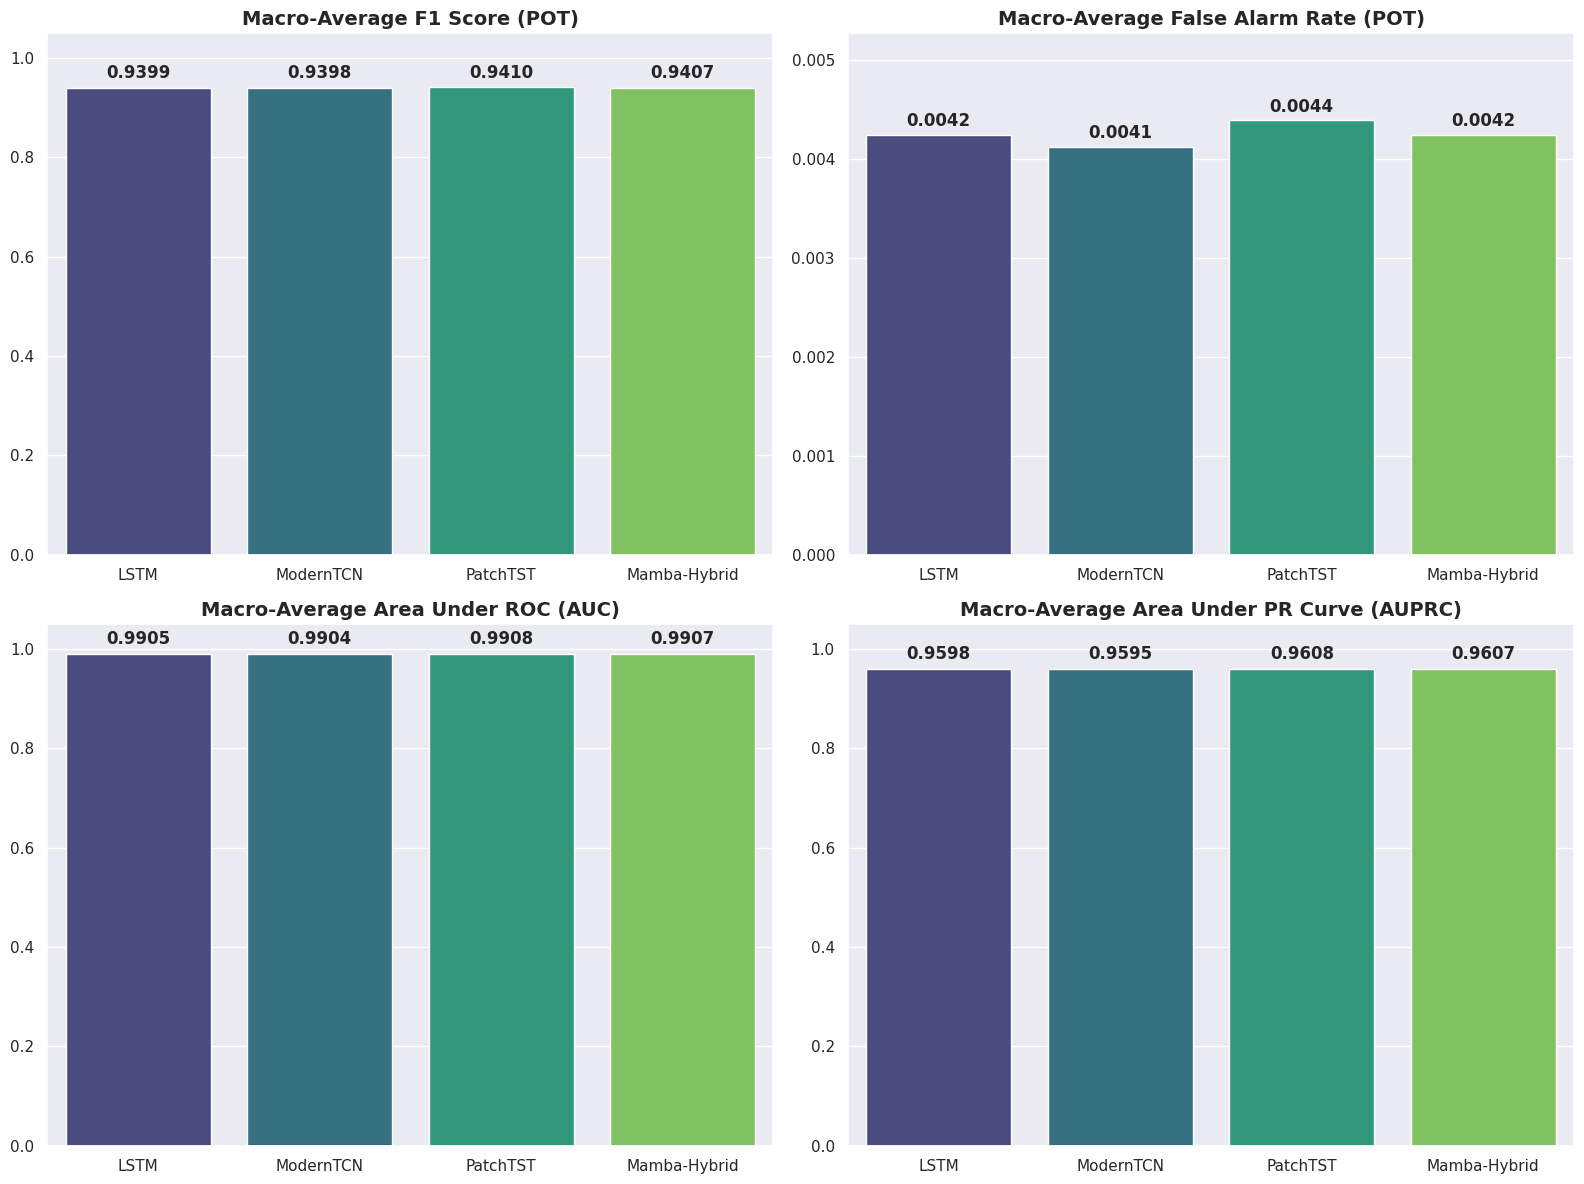

/tmp/ipykernel_23/3906567111.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=calib_vals, y=calib_methods, ax=axes2[1], palette='rocket', orient='h')


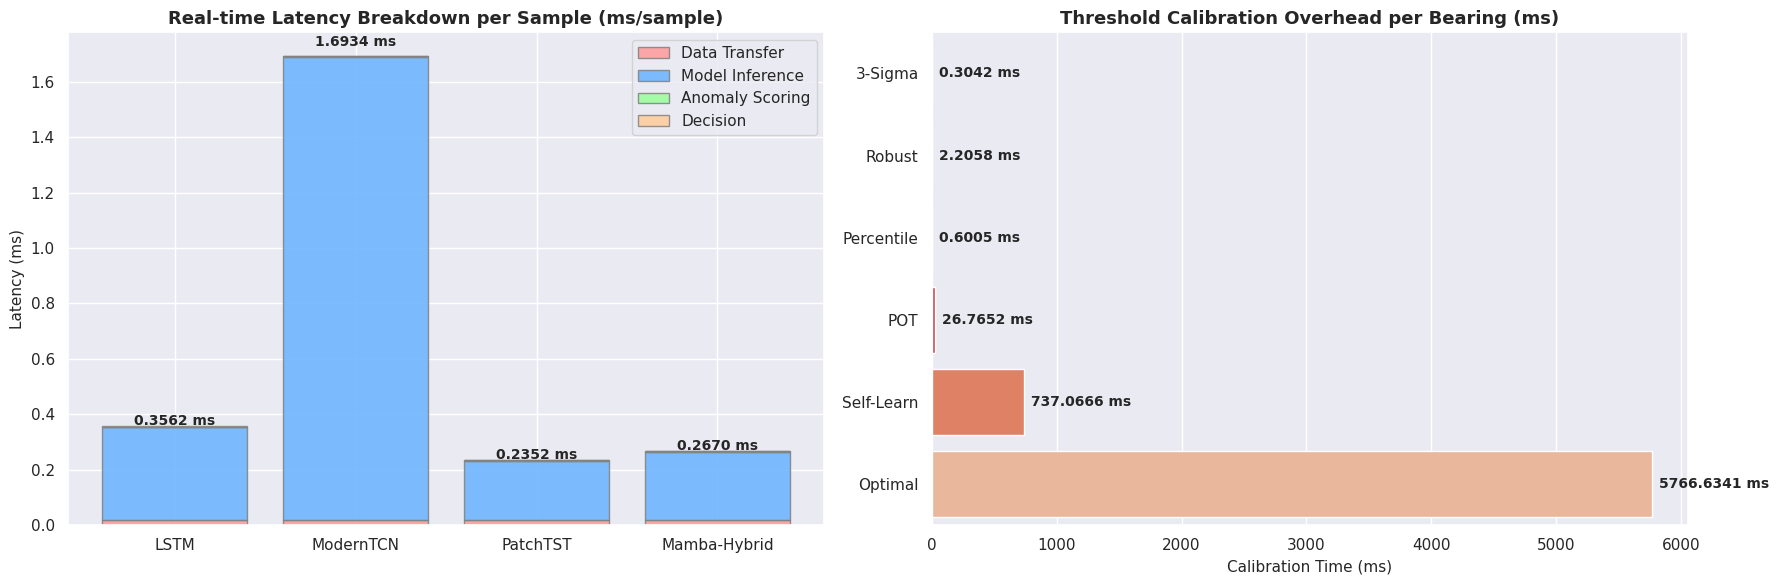

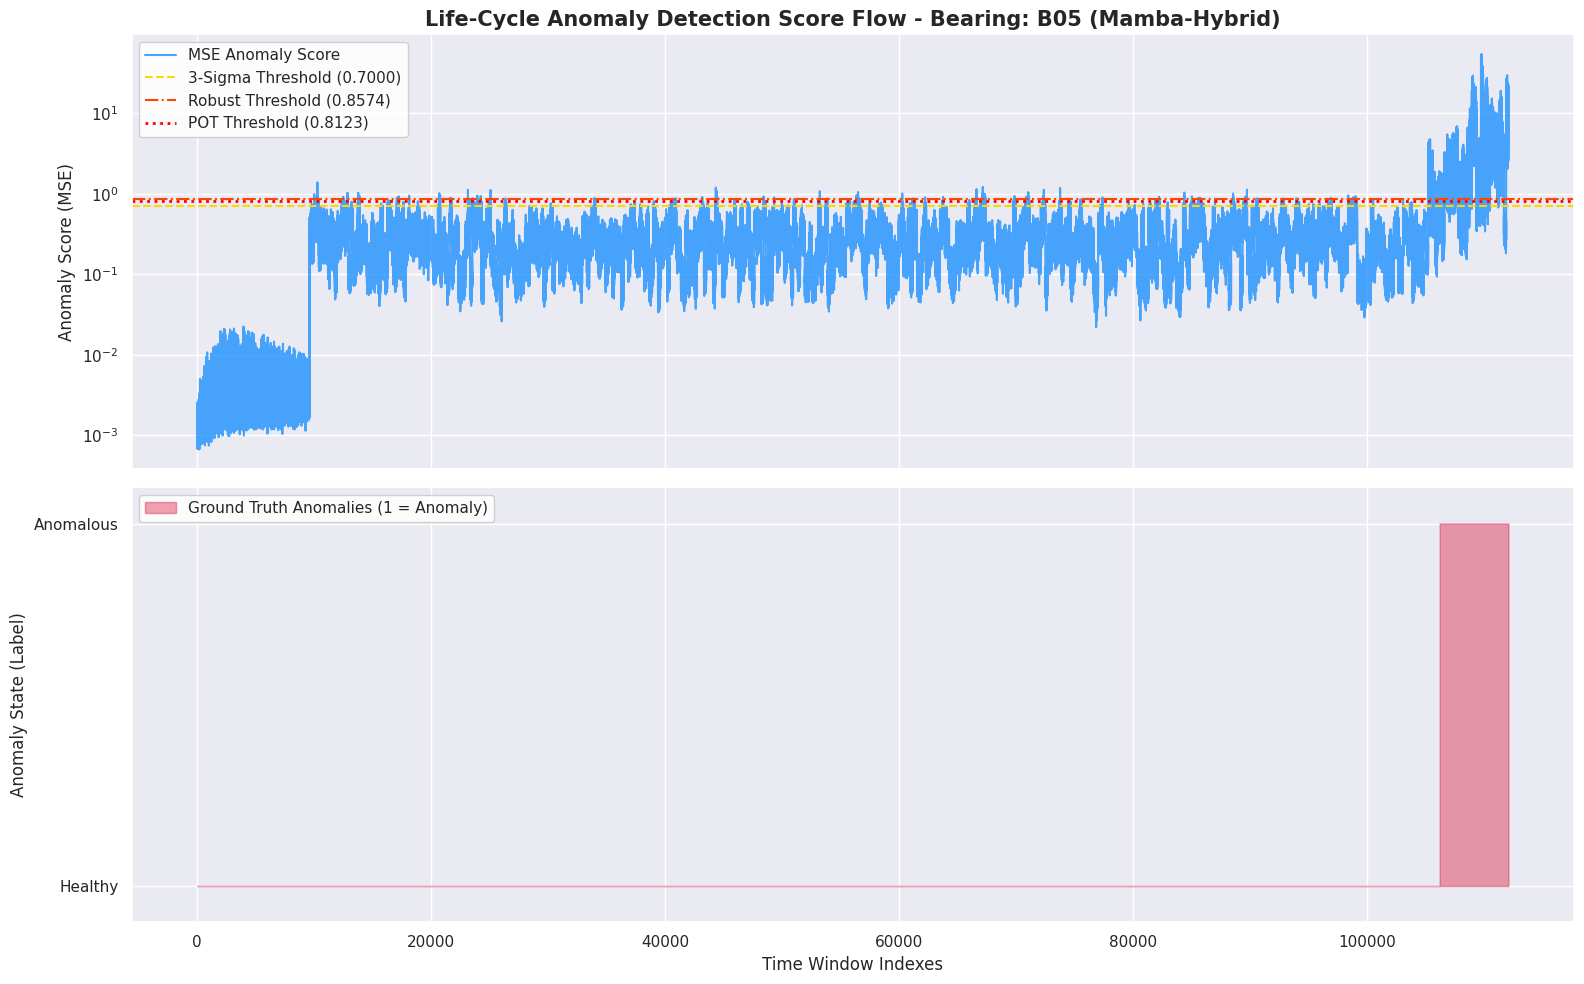

In [8]:
# 7. Trực quan hóa và So sánh Kết quả (Bar Charts & Anomaly Scores Flow)
if results:
    sns.set_theme(style='darkgrid')
    
    # Biểu đồ 1: So sánh 4 chỉ số Anomaly Detection 2x2
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    model_names = list(results.keys())
    
    f1_scores = [results[m]['f1_pot'] for m in model_names]
    far_scores = [results[m]['far_pot'] for m in model_names]
    auc_scores = [results[m]['auc'] for m in model_names]
    auprc_scores = [results[m]['auprc'] for m in model_names]
    
    palette = sns.color_palette("viridis", len(model_names))
    
    # Sub-plot 1: F1 (POT)
    sns.barplot(x=model_names, y=f1_scores, ax=axes[0, 0], palette=palette)
    axes[0, 0].set_title('Macro-Average F1 Score (POT)', fontsize=14, fontweight='bold')
    axes[0, 0].set_ylim(0, 1.05)
    for i, v in enumerate(f1_scores):
        axes[0, 0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
        
    # Sub-plot 2: FAR (POT)
    sns.barplot(x=model_names, y=far_scores, ax=axes[0, 1], palette=palette)
    axes[0, 1].set_title('Macro-Average False Alarm Rate (POT)', fontsize=14, fontweight='bold')
    axes[0, 1].set_ylim(0, max(far_scores) * 1.2 if max(far_scores) > 0 else 0.1)
    for i, v in enumerate(far_scores):
        axes[0, 1].text(i, v + (max(far_scores) * 0.02 if max(far_scores) > 0 else 0.002), f"{v:.4f}", ha='center', fontweight='bold')
        
    # Sub-plot 3: AUC
    sns.barplot(x=model_names, y=auc_scores, ax=axes[1, 0], palette=palette)
    axes[1, 0].set_title('Macro-Average Area Under ROC (AUC)', fontsize=14, fontweight='bold')
    axes[1, 0].set_ylim(0, 1.05)
    for i, v in enumerate(auc_scores):
        axes[1, 0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
        
    # Sub-plot 4: AUPRC
    sns.barplot(x=model_names, y=auprc_scores, ax=axes[1, 1], palette=palette)
    axes[1, 1].set_title('Macro-Average Area Under PR Curve (AUPRC)', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylim(0, 1.05)
    for i, v in enumerate(auprc_scores):
        axes[1, 1].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
        
    plt.tight_layout()
    plt.show()
    
    # Biểu đồ mới: Phân tích độ trễ phát hiện thời gian thực (Stacked Latency Breakdown) & Độ trễ hiệu chuẩn ngưỡng
    fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))
    
    # Chuẩn bị dữ liệu cho Latency Breakdown
    categories = ['Data Transfer', 'Model Inference', 'Anomaly Scoring', 'Decision']
    latency_data = {m: [
        results[m]['latency_breakdown']['data_transfer'],
        results[m]['latency_breakdown']['inference'],
        results[m]['latency_breakdown']['scoring'],
        results[m]['latency_breakdown']['decision']
    ] for m in model_names if 'latency_breakdown' in results[m]}
    
    if latency_data:
        # Stacked bar plot
        bottom = np.zeros(len(model_names))
        colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
        
        for idx, cat in enumerate(categories):
            vals = [latency_data[m][idx] for m in model_names]
            axes2[0].bar(model_names, vals, bottom=bottom, label=cat, color=colors[idx], edgecolor='gray', alpha=0.85)
            bottom += vals
            
        axes2[0].set_title('Real-time Latency Breakdown per Sample (ms/sample)', fontsize=13, fontweight='bold')
        axes2[0].set_ylabel('Latency (ms)', fontsize=11)
        axes2[0].legend(loc='upper right')
        
        # Add text labels for total latency on top of bars
        for idx, m in enumerate(model_names):
            total_val = results[m]['latency']
            axes2[0].text(idx, total_val + (total_val * 0.02), f"{total_val:.4f} ms", ha='center', fontweight='bold', fontsize=10)
    else:
        # Fallback to simple bar plot if breakdown is missing
        latencies = [results[m]['latency'] for m in model_names]
        sns.barplot(x=model_names, y=latencies, ax=axes2[0], palette=palette)
        axes2[0].set_title('Average Real-time Latency per Sample (ms)', fontsize=13, fontweight='bold')
        axes2[0].set_ylabel('Latency (ms)', fontsize=11)
        for i, v in enumerate(latencies):
            axes2[0].text(i, v + 0.02, f"{v:.4f} ms", ha='center', fontweight='bold')

    # Độ trễ hiệu chuẩn ngưỡng (Threshold Calibration Overhead)
    first_model = model_names[0]
    if 'calib_latencies' in results[first_model]:
        calib_methods = list(results[first_model]['calib_latencies'].keys())
        calib_vals = list(results[first_model]['calib_latencies'].values())
        
        sns.barplot(x=calib_vals, y=calib_methods, ax=axes2[1], palette='rocket', orient='h')
        axes2[1].set_title('Threshold Calibration Overhead per Bearing (ms)', fontsize=13, fontweight='bold')
        axes2[1].set_xlabel('Calibration Time (ms)', fontsize=11)
        for i, v in enumerate(calib_vals):
            axes2[1].text(v + (max(calib_vals) * 0.01 if max(calib_vals) > 0 else 0.1), i, f"{v:.4f} ms", va='center', fontweight='bold', fontsize=10)
            
    plt.tight_layout()
    plt.show()

    # Biểu đồ 2: Luồng Điểm số Bất thường qua toàn bộ Life-Cycle
    best_model_name = 'Mamba-Hybrid' if 'Mamba-Hybrid' in results else list(results.keys())[0]
    if best_model_name not in results and 'Mamba1-Hybrid' in results:
        best_model_name = 'Mamba1-Hybrid'
    last_bearing = results[best_model_name]['last_bearing']
    
    if last_bearing:
        scores = last_bearing['scores']
        labels = last_bearing['labels']
        bearing_name = last_bearing['bearing_name']
        th_3sigma = last_bearing['th_3sigma']
        th_robust = last_bearing['th_robust']
        th_pot = last_bearing['th_pot']
        
        timesteps = np.arange(len(scores))
        
        fig3, axes3 = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
        
        # Sub-plot 1: Anomaly Scores Flow and Calibrated Thresholds
        axes3[0].plot(timesteps, scores, label='MSE Anomaly Score', color='dodgerblue', alpha=0.8, linewidth=1.5)
        axes3[0].axhline(y=th_3sigma, color='gold', linestyle='--', label=f'3-Sigma Threshold ({th_3sigma:.4f})', linewidth=1.5)
        axes3[0].axhline(y=th_robust, color='orangered', linestyle='-.', label=f'Robust Threshold ({th_robust:.4f})', linewidth=1.5)
        axes3[0].axhline(y=th_pot, color='red', linestyle=':', label=f'POT Threshold ({th_pot:.4f})', linewidth=2)
        
        axes3[0].set_title(f'Life-Cycle Anomaly Detection Score Flow - Bearing: {bearing_name} ({best_model_name})', fontsize=15, fontweight='bold')
        axes3[0].set_ylabel('Anomaly Score (MSE)', fontsize=12)
        axes3[0].legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
        axes3[0].set_yscale('log')
        
        # Sub-plot 2: Ground Truth Anomaly Labels
        axes3[1].fill_between(timesteps, labels, color='crimson', alpha=0.4, label='Ground Truth Anomalies (1 = Anomaly)')
        axes3[1].set_ylabel('Anomaly State (Label)', fontsize=12)
        axes3[1].set_xlabel('Time Window Indexes', fontsize=12)
        axes3[1].set_ylim(-0.1, 1.1)
        axes3[1].set_yticks([0, 1])
        axes3[1].set_yticklabels(['Healthy', 'Anomalous'])
        axes3[1].legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.9)
        
        plt.tight_layout()
        plt.show()
else:
    print("Không có dữ liệu trực quan vì không có mô hình nào được đánh giá.")
